# Load, Reshape, And Plot SST

This notebook samples the model setup patterns from:

- `ASTE_270/Pemberton_BarentsSpaper/2026_BarentsS/validate_all_pkg_layers_miniaste/FULL_MINIASTE_WALKTHROUGH.ipynb`
- `ASTE_270/Pemberton_BarentsSpaper/2026_BarentsS/validate_all_pkg_layers_aste270/validate_alleqs_aste270.ipynb`

It loads one random `state_3d_set1` timestep from each declared model setup, reads the `THETA` record, reshapes it from compact coordinates, and plots the surface-temperature distribution.

In [8]:
from pathlib import Path
import sys

CRIOS_BACKUPS_DIR = Path("/home/mmurakami/crios_backups")
ASTE_TOOLS_DIR = CRIOS_BACKUPS_DIR / "aste_tools"
ASTE_DIR = CRIOS_BACKUPS_DIR / "ASTE_270"
ASTE_TOOLS_HELPERS_DIR = ASTE_TOOLS_DIR / "an_helper_functions"
AN_HELPERS_DIR = CRIOS_BACKUPS_DIR / "an_helper_functions"
MITGCMUTILS_DIR = Path("/home/mmurakami/MITgcm/MITgcm_c68r/MITgcm-checkpoint68r/utils/python/MITgcmutils/MITgcmutils")

for path in [AN_HELPERS_DIR, ASTE_TOOLS_DIR, ASTE_TOOLS_HELPERS_DIR, MITGCMUTILS_DIR]:
    if path.exists() and str(path) not in sys.path:
        sys.path.insert(0, str(path))

# Declared ASTE directories from the source notebooks.
MINIASTE_DIR = Path("/scratch3/atnguyen/aste_90x150x60")
MINIASTE_RUN = "run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001_r8_07May2026_pfe"
ASTE270_FORWARD_DIR = Path("/scratch/atnguyen/aste_270x450x180/OFFICIAL_ASTE_R1_Sep2019")
ASTE270_LAYERS_DIR = Path("/scratch3/atnguyen/aste_270x450x180/run_c68v_layers_lessmem1_adxOFF_Jan2007_capxxN50_it0062_pk0000262944_bro")

ASTE_TOOLS_DIR, ASTE_TOOLS_HELPERS_DIR, ASTE_DIR, MINIASTE_DIR, ASTE270_FORWARD_DIR

(PosixPath('/home/mmurakami/crios_backups/aste_tools'),
 PosixPath('/home/mmurakami/crios_backups/aste_tools/an_helper_functions'),
 PosixPath('/home/mmurakami/crios_backups/ASTE_270'),
 PosixPath('/scratch3/atnguyen/aste_90x150x60'),
 PosixPath('/scratch/atnguyen/aste_270x450x180/OFFICIAL_ASTE_R1_Sep2019'))

In [9]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt

from mds import parsemeta, rdmds
from aste_helper_funcs import get_aste_faces
from aste_tools.grid import aste90, aste270, compact_to_tracer

plt.rcParams["figure.figsize"] = (12, 5)

In [10]:
MODEL_SETUPS = {
    "miniASTE": {
        "grid": aste90(),
        "dirstate": MINIASTE_DIR / MINIASTE_RUN / "diags" / "STATE",
        "file_name": "state_3d_set1",
        "source_tsstr": np.array(["0000000003", "0000000004"]),
        "source_notebook": "FULL_MINIASTE_WALKTHROUGH.ipynb",
    },
    "ASTE270": {
        "grid": aste270(),
        "dirstate": ASTE270_FORWARD_DIR / "diags" / "STATE",
        "file_name": "state_3d_set1",
        "source_months": {"2007": np.arange(3, 5, 1)},
        "source_notebook": "validate_alleqs_aste270.ipynb",
    },
}

MODEL_SETUPS

{'miniASTE': {'grid': ASTEGridSpec(nx=90, ncut1=150, ncut2=60, nz=50, name='aste90'),
  'dirstate': PosixPath('/scratch3/atnguyen/aste_90x150x60/run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001_r8_07May2026_pfe/diags/STATE'),
  'file_name': 'state_3d_set1',
  'source_tsstr': array(['0000000003', '0000000004'], dtype='<U10'),
  'source_notebook': 'FULL_MINIASTE_WALKTHROUGH.ipynb'},
 'ASTE270': {'grid': ASTEGridSpec(nx=270, ncut1=450, ncut2=180, nz=50, name='aste270'),
  'dirstate': PosixPath('/scratch/atnguyen/aste_270x450x180/OFFICIAL_ASTE_R1_Sep2019/diags/STATE'),
  'file_name': 'state_3d_set1',
  'source_months': {'2007': array([3, 4])},
  'source_notebook': 'validate_alleqs_aste270.ipynb'}}

In [11]:
def available_timesteps(dirstate, file_name):
    """Return timestep strings from existing MITgcm metadata files."""
    dirstate = Path(dirstate)
    pattern = re.compile(rf"{re.escape(file_name)}\.(\d+)\.meta$")
    steps = []
    for meta_path in dirstate.glob(f"{file_name}.*.meta"):
        match = pattern.search(meta_path.name)
        if match:
            steps.append(match.group(1))
    return np.array(sorted(set(steps)))


def choose_random_timestep(setup, rng=None):
    """Choose one timestep from available files, falling back to source-notebook tsstr."""
    rng = np.random.default_rng() if rng is None else rng
    steps = available_timesteps(setup["dirstate"], setup["file_name"])
    if steps.size == 0 and "source_tsstr" in setup:
        steps = setup["source_tsstr"]
    if steps.size == 0:
        raise FileNotFoundError(
            f"No {setup['file_name']} metadata found in {setup['dirstate']}. "
            "Update the declared model path or mount the scratch directory."
        )
    return str(rng.choice(steps))


def theta_record_index(dirstate, file_name, timestep):
    """Find the THETA record number from the timestep metadata."""
    meta = parsemeta(str(Path(dirstate) / f"{file_name}.{timestep}.meta"))
    fldlist = np.array(meta["fldList"])
    hits = np.where(fldlist == "THETA")[0]
    if hits.size == 0:
        raise ValueError(f"THETA not found in {file_name}.{timestep}.meta; fields={fldlist}")
    return int(hits[0])


def load_sst_sample(setup, rng=None):
    """Load one random compact THETA timestep and return compact/map SST."""
    grid = setup["grid"]
    timestep = choose_random_timestep(setup, rng=rng)
    rec = theta_record_index(setup["dirstate"], setup["file_name"], timestep)
    theta, its, meta = rdmds(
        str(Path(setup["dirstate"]) / setup["file_name"]),
        int(timestep),
        returnmeta=True,
        rec=rec,
    )
    theta = theta.reshape(grid.compact_shape_3d)
    sst_compact = theta[0].astype(float)
    sst_compact[sst_compact == 0] = np.nan
    sst_map = compact_to_tracer(sst_compact, grid)
    return {
        "timestep": timestep,
        "record": rec,
        "sst_compact": sst_compact,
        "sst_map": sst_map,
        "its": its,
        "meta": meta,
    }

In [12]:
# Leave unseeded for a fresh random draw each run. Set to an integer for reproducibility.
RNG_SEED = None
rng = np.random.default_rng(RNG_SEED)

samples = {}
for name, setup in MODEL_SETUPS.items():
    samples[name] = load_sst_sample(setup, rng=rng)
    print(
        name,
        "timestep=", samples[name]["timestep"],
        "THETA record=", samples[name]["record"],
        "map shape=", samples[name]["sst_map"].shape,
        "source=", setup["source_notebook"],
    )

miniASTE timestep= 0000000003 THETA record= 0 map shape= (300, 180) source= FULL_MINIASTE_WALKTHROUGH.ipynb
ASTE270 timestep= 0000245376 THETA record= 0 map shape= (900, 540) source= validate_alleqs_aste270.ipynb


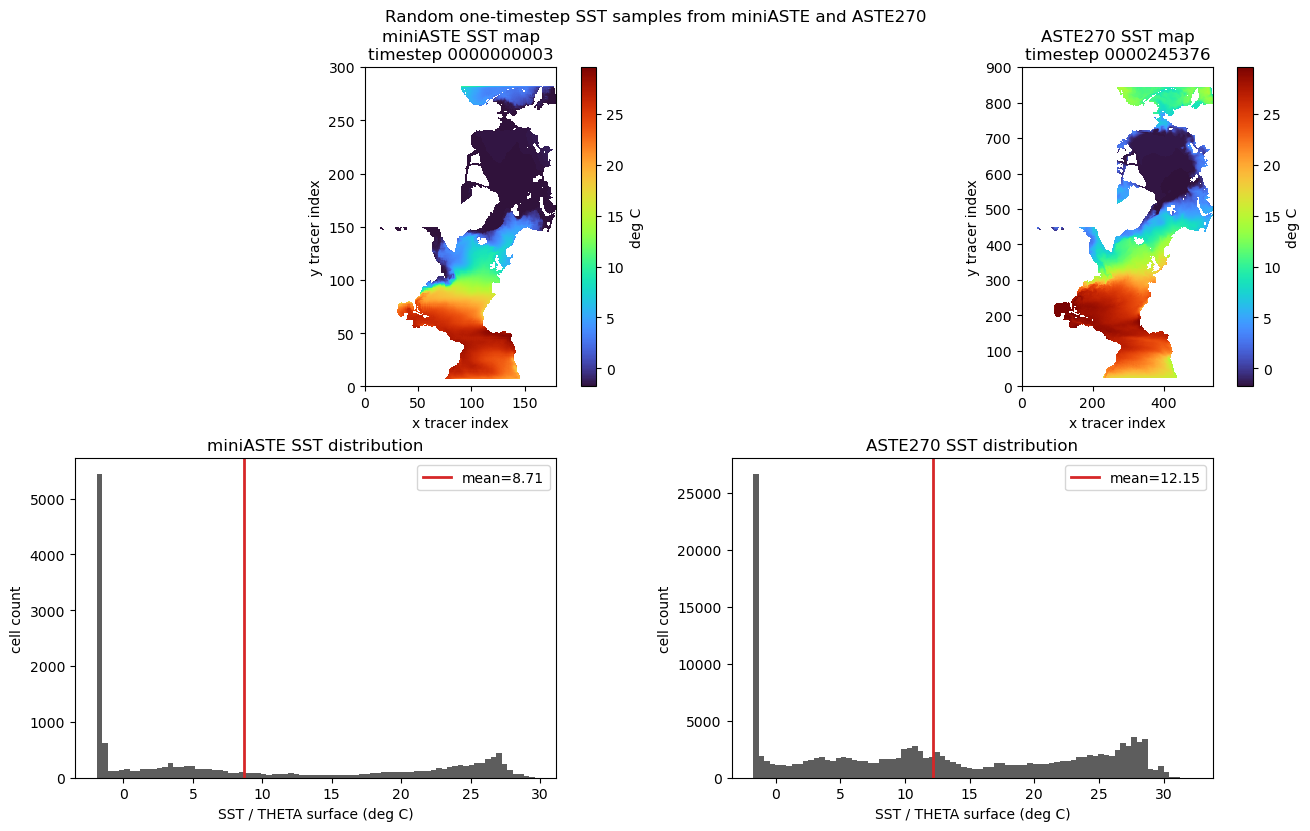

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)

all_values = np.concatenate([
    sample["sst_map"][np.isfinite(sample["sst_map"])]
    for sample in samples.values()
])
vmin, vmax = np.nanpercentile(all_values, [1, 99])

for col, (name, sample) in enumerate(samples.items()):
    sst_map = sample["sst_map"]
    ax_map = axes[0, col]
    pcm = ax_map.pcolormesh(sst_map, cmap="turbo", vmin=vmin, vmax=vmax, shading="auto")
    ax_map.set_title(f"{name} SST map\ntimestep {sample['timestep']}")
    ax_map.set_aspect("equal")
    ax_map.set_xlabel("x tracer index")
    ax_map.set_ylabel("y tracer index")
    fig.colorbar(pcm, ax=ax_map, label="deg C")

    ax_hist = axes[1, col]
    vals = sst_map[np.isfinite(sst_map)]
    ax_hist.hist(vals, bins=80, color="0.25", alpha=0.85)
    ax_hist.set_title(f"{name} SST distribution")
    ax_hist.set_xlabel("SST / THETA surface (deg C)")
    ax_hist.set_ylabel("cell count")
    ax_hist.axvline(np.nanmean(vals), color="tab:red", lw=2, label=f"mean={np.nanmean(vals):.2f}")
    ax_hist.legend()

fig.suptitle("Random one-timestep SST samples from miniASTE and ASTE270", y=1.02)
plt.show()

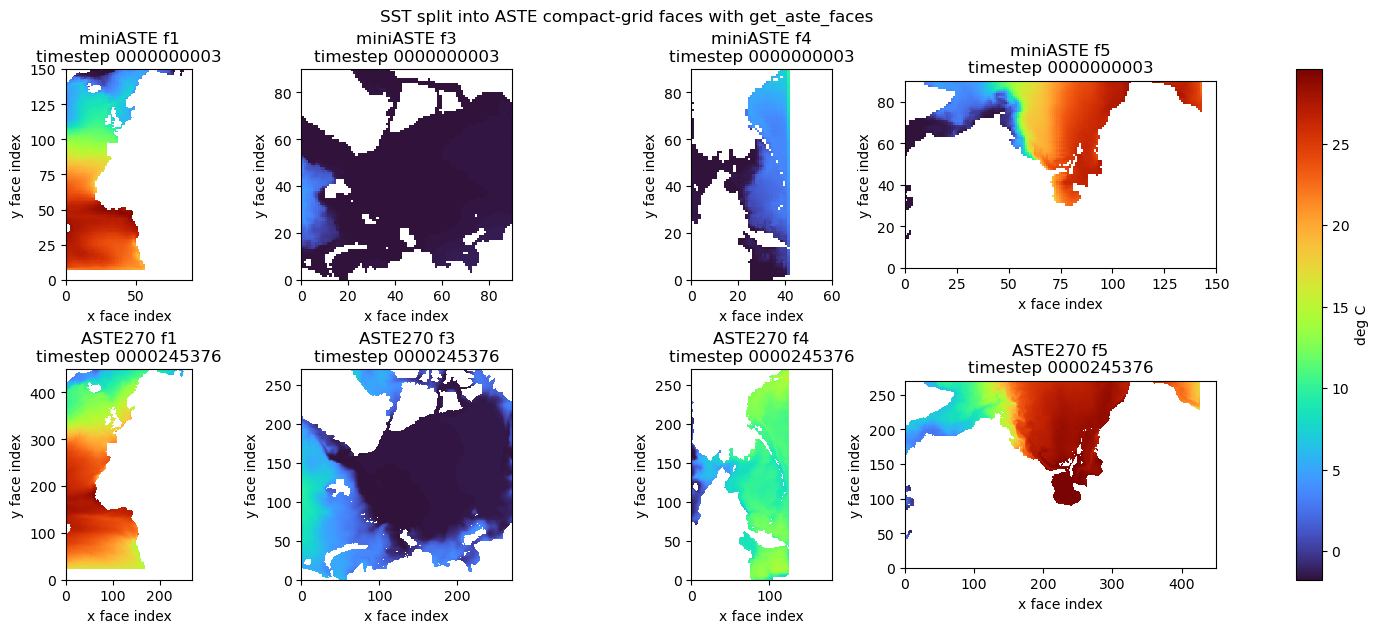

In [14]:
face_names = ["f1", "f3", "f4", "f5"]
fig, axes = plt.subplots(len(samples), len(face_names), figsize=(15, 6), constrained_layout=True)

if len(samples) == 1:
    axes = np.array([axes])

for row, (name, sample) in enumerate(samples.items()):
    grid = MODEL_SETUPS[name]["grid"]
    faces = get_aste_faces(sample["sst_compact"], grid.nfx, grid.nfy)

    for col, face_name in enumerate(face_names):
        ax = axes[row, col]
        face = getattr(faces, face_name)[0]
        pcm = ax.pcolormesh(face, cmap="turbo", vmin=vmin, vmax=vmax, shading="auto")
        ax.set_title(f"{name} {face_name}\ntimestep {sample['timestep']}")
        ax.set_aspect("equal")
        ax.set_xlabel("x face index")
        ax.set_ylabel("y face index")

fig.colorbar(pcm, ax=axes.ravel().tolist(), label="deg C")
fig.suptitle("SST split into ASTE compact-grid faces with get_aste_faces", y=1.03)
plt.show()